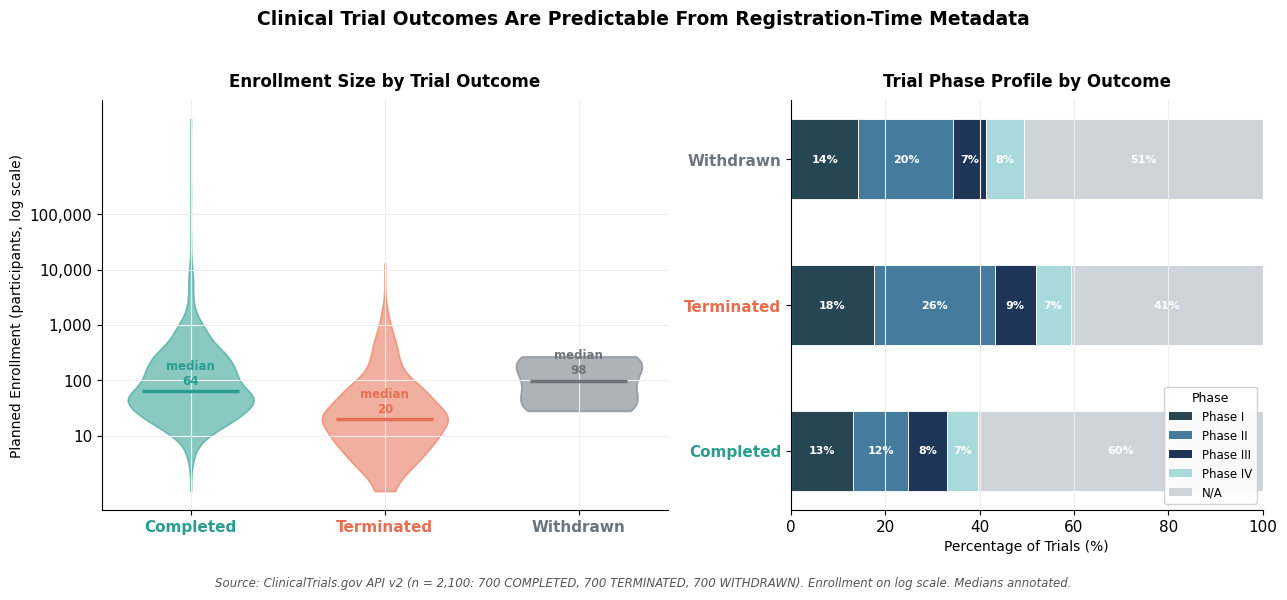

Saved to ../visualizations/press_release_viz.png


In [2]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from pathlib import Path

# ── Load raw data ─────────────────────────────────────────────────────────────
with open("../data/raw/clinical_trials_raw.json", "r", encoding="utf-8") as f:
    studies = json.load(f)

# ── Extract features ──────────────────────────────────────────────────────────
records = []
for doc in studies:
    try:
        ps     = doc["protocolSection"]
        status = ps["statusModule"]["overallStatus"]

        enrollment = None
        try:
            enrollment = int(ps["designModule"]["enrollmentInfo"]["count"])
        except (KeyError, TypeError, ValueError):
            pass

        phases = []
        try:
            phases = ps["designModule"].get("phases", [])
        except (KeyError, AttributeError):
            pass
        phase = phases[0] if phases else "N/A"

        # Collapse verbose phase labels
        phase_map = {
            "PHASE1": "Phase I",
            "PHASE2": "Phase II",
            "PHASE3": "Phase III",
            "PHASE4": "Phase IV",
            "NA":     "N/A",
            "N/A":    "N/A",
        }
        phase = phase_map.get(phase, "N/A")

        records.append({"status": status, "enrollment": enrollment, "phase": phase})
    except Exception:
        pass

df = pd.DataFrame(records)

# ── Palette & style ───────────────────────────────────────────────────────────
STATUS_ORDER  = ["COMPLETED", "TERMINATED", "WITHDRAWN"]
STATUS_COLORS = {"COMPLETED": "#2A9D8F", "TERMINATED": "#E76F51", "WITHDRAWN": "#6C757D"}
PHASE_ORDER   = ["Phase I", "Phase II", "Phase III", "Phase IV", "N/A"]
PHASE_COLORS  = ["#264653", "#457B9D", "#1D3557", "#A8DADC", "#CED4DA"]

plt.rcParams.update({
    "font.family":      "sans-serif",
    "font.size":        11,
    "axes.spines.top":  False,
    "axes.spines.right":False,
    "axes.grid":        True,
    "grid.color":       "#EEEEEE",
    "grid.linewidth":   0.8,
})

fig, (ax1, ax2) = plt.subplots(
    1, 2,
    figsize=(13, 5.5),
    gridspec_kw={"width_ratios": [1.2, 1]},
)
fig.patch.set_facecolor("white")

# ── Panel 1: Enrollment distributions (violin + strip) ───────────────────────
enroll_df = df[df["enrollment"].notna() & (df["enrollment"] > 0)].copy()
enroll_df["log_enrollment"] = np.log10(enroll_df["enrollment"])

for i, status in enumerate(STATUS_ORDER):
    sub   = enroll_df[enroll_df["status"] == status]["log_enrollment"].values
    color = STATUS_COLORS[status]

    # Violin
    vp = ax1.violinplot(sub, positions=[i], widths=0.65,
                        showmedians=False, showextrema=False)
    for body in vp["bodies"]:
        body.set_facecolor(color)
        body.set_alpha(0.55)
        body.set_edgecolor(color)
        body.set_linewidth(1.2)

    # Median line
    med = np.median(sub)
    ax1.hlines(med, i - 0.25, i + 0.25, color=color, linewidth=2.5, zorder=5)

    # Annotation
    ax1.text(i, med + 0.07, f"median\n{10**med:,.0f}",
             ha="center", va="bottom", fontsize=8.5, color=color, fontweight="bold")

ax1.set_xticks(range(len(STATUS_ORDER)))
ax1.set_xticklabels(
    [s.capitalize() if s != "N/A" else s for s in STATUS_ORDER],
    fontsize=11, fontweight="bold",
)
ax1.set_ylabel("Planned Enrollment (participants, log scale)", fontsize=10)
ax1.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda val, _: f"{int(10**val):,}" if val == int(val)
                          else f"{10**val:,.0f}")
)
ax1.set_yticks([1, 2, 3, 4, 5])
ax1.set_yticklabels(["10", "100", "1,000", "10,000", "100,000"])
ax1.set_title("Enrollment Size by Trial Outcome", fontsize=12, fontweight="bold", pad=10)

for i, status in enumerate(STATUS_ORDER):
    ax1.get_xticklabels()[i].set_color(STATUS_COLORS[status])

# ── Panel 2: Phase distribution (100% stacked horizontal bar) ────────────────
phase_df    = df.groupby(["status", "phase"]).size().unstack(fill_value=0)
# Ensure all phase columns present
for p in PHASE_ORDER:
    if p not in phase_df.columns:
        phase_df[p] = 0
phase_df = phase_df[PHASE_ORDER]
phase_pct = phase_df.div(phase_df.sum(axis=1), axis=0) * 100

bar_height = 0.55
for row_i, status in enumerate(STATUS_ORDER):
    left = 0
    for col_i, phase in enumerate(PHASE_ORDER):
        val   = phase_pct.loc[status, phase]
        color = PHASE_COLORS[col_i]
        ax2.barh(row_i, val, left=left, height=bar_height,
                 color=color, edgecolor="white", linewidth=0.6)
        if val > 6:
            ax2.text(left + val / 2, row_i, f"{val:.0f}%",
                     ha="center", va="center", fontsize=8, color="white", fontweight="bold")
        left += val

ax2.set_yticks(range(len(STATUS_ORDER)))
ax2.set_yticklabels(
    [s.capitalize() for s in STATUS_ORDER],
    fontsize=11, fontweight="bold",
)
for i, status in enumerate(STATUS_ORDER):
    ax2.get_yticklabels()[i].set_color(STATUS_COLORS[status])

ax2.set_xlabel("Percentage of Trials (%)", fontsize=10)
ax2.set_xlim(0, 100)
ax2.set_title("Trial Phase Profile by Outcome", fontsize=12, fontweight="bold", pad=10)
ax2.grid(axis="y", visible=False)

# Phase legend
legend_patches = [
    plt.Rectangle((0, 0), 1, 1, facecolor=PHASE_COLORS[i], label=PHASE_ORDER[i])
    for i in range(len(PHASE_ORDER))
]
ax2.legend(
    handles=legend_patches, loc="lower right",
    frameon=True, framealpha=0.9, fontsize=8.5,
    title="Phase", title_fontsize=9,
)

# ── Shared caption ────────────────────────────────────────────────────────────
fig.text(
    0.5, -0.03,
    "Source: ClinicalTrials.gov API v2 (n = 2,100: 700 COMPLETED, 700 TERMINATED, 700 WITHDRAWN). "
    "Enrollment on log scale. Medians annotated.",
    ha="center", fontsize=8.5, color="#555555", style="italic",
)

plt.suptitle(
    "Clinical Trial Outcomes Are Predictable From Registration-Time Metadata",
    fontsize=13.5, fontweight="bold", y=1.02,
)

plt.tight_layout()
plt.savefig("../visualizations/press_release_viz.png",
            dpi=180, bbox_inches="tight", facecolor="white")
plt.show()
print("Saved to ../visualizations/press_release_viz.png")